<a href="https://colab.research.google.com/github/gilIolgenblum/CrowdingModeWorkshop/blob/main/tutorials/02_fit_experimental_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Fit to Experimental Data

## Goal
In this tutorial, you will learn how to fit the soft interaction parameters ($\varepsilon$ and $\varepsilon_{TS}$) to experimental protein stability data using the binary crowding model.

We will use experimental data for the AQ16 peptide in the presence of Trehalose.

## Setup
First, we import the package, as well as `pandas` for data handling and `matplotlib` for plotting.

![Fit Data Workflow](assets/fit_data_flowchart.svg)

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/CrowdingModeWorkshop.git
    # Change the working directory to the repository root
    os.chdir('/content/CrowdingModeWorkshop')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/CrowdingModeWorkshop/src')

In [2]:
import crowding as cr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Module imported successfully: {cr.__name__}")

Module imported successfully: crowding


## Load Experimental Data
The package includes sample datasets in `app/sample_data/`. Let's load the binary Trehalose dataset.

This dataset has the following columns:
- `concentration`: The concentration of Trehalose in **Molal** ($m$).
- `dG`: $\Delta\Delta G^0$ in **kJ/mol**.
- `dH`: $\Delta\Delta H^0$ in **kJ/mol**.
- `TdS`: $T\Delta\Delta S^0$ in **kJ/mol**.

*Note that missing values are represented as empty cells (which Pandas parses as `NaN`).*

In [3]:
# Locate the sample data path
ROOT = Path.cwd()
while not (ROOT / "app").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

sample_data_path = ROOT / "app" / "sample_data" / "aq16_trehalose_binary_format1.csv"

# Load the data
df = pd.read_csv(sample_data_path)
display(df.head(10))

,concentration,dG,dH,TdS
0,0.23633,-0.150580,-1.141388,-0.638512
1,0.40000,-0.194600,-1.054160,-0.611100
2,0.42002,-0.209320,-1.079912,-0.641647
3,0.56689,-0.341060,-1.417496,-0.949190
4,0.68700,-0.403860,-1.731230,-1.215184
5,0.78705,-0.483330,-1.944063,-1.374752
6,0.78913,-0.483640,-1.990017,-1.340680
7,0.80000,-0.502711,-1.953060,-1.402100
8,0.95123,-0.614650,-2.305377,-1.600458
9,1.07308,-0.652490,-2.570575,-1.760719


## Data Preparation
The package natively handles Molal concentrations during fitting, so we don't need to manually convert the concentration to volume fraction ($\phi$), we just need to tell the model `concentration_type='molal'` later.
The energies are already in **kJ/mol**, which is exactly what the model expects.

In [4]:
# Drop NaNs to create specific arrays for each fit
# For dG (eps fitting)
df_dG = df.dropna(subset=["concentration", "dG"])
exp_conc_G = df_dG["concentration"].values
exp_dG = df_dG["dG"].values

# For dH and TdS (epsTS fitting)
df_H_S = df.dropna(subset=["concentration", "dH", "TdS"])
exp_conc_HS = df_H_S["concentration"].values
exp_dH = df_H_S["dH"].values
exp_TdS = df_H_S["TdS"].values

## Define Model Parameters
To construct the model, we need the properties of AQ16 (Protein) and Trehalose (Cosolute).

For AQ16, the measured SASA is $242.6 \ \mathring{A}^2$.
For Trehalose, the physical parameters are roughly $
u=11.7$, $\chi=0.433$, and $\chi_{TS}=-1.12$.

In [5]:
# Define Protein
AQ16 = cr.Protein(SASA=242.6)

# Define Trehalose Cosolute
trehalose = cr.Cosolute(
    nu=11.70, chi=0.433, chiTS=-1.120
)

# Initialize the model (we start with eps=0.0 and epsTS=0.0)
# We set a large enough phiC_max to ensure our experimental range is covered.
# Molal concentrations of ~1.3 m correspond to roughly phi=0.22.
model = cr.CrowdingModel(
    protein=AQ16,
    cosolute=trehalose,
    eps=0.0,
    epsTS=0.0,
    phiC_max=0.22,
    dphiC=0.0001,
    T=298.15
)

## Fit $\varepsilon$ from $\Delta\Delta G^0$
First, we fit the primary soft interaction parameter $\varepsilon$ using the $\Delta\Delta G^0$ data.
We use the `fit_eps` method and explicitly pass `concentration_type="molal"`.

In [6]:
# Fit eps
model.fit_eps(
    exp_conc=exp_conc_G,
    exp_ddG=exp_dG,
    concentration_type='molal',
    progress_bar=True
)

print(f"Fitted eps: {model.eps:.4f}")

Fitting eps: 0iter [00:00, ?iter/s]

Optimization terminated successfully.
         Current function value: 0.028086
         Iterations: 6
         Function evaluations: 20
         Gradient evaluations: 10
Fitted eps: -0.0443


## Fit $\varepsilon_{TS}$ from $\Delta\Delta H^0$ and $T\Delta\Delta S^0$
Next, now that $\varepsilon$ is fixed, we can fit the entropic component of the soft interactions ($\varepsilon_{TS}$) using the enthalpic and entropic data.

In [7]:
# Fit epsTS
model.fit_epsTS(
    exp_conc=exp_conc_HS,
    exp_ddH=exp_dH,
    exp_TddS=exp_TdS,
    concentration_type='molal',
    progress_bar=True
)

print(f"Fitted epsTS: {model.epsTS:.4f}")

print('----------------------\n',model)

Fitting epsTS: 0iter [00:00, ?iter/s]

/home/gilo/miniforge3/envs/gilo2/lib/python3.11/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.549961
         Iterations: 1
         Function evaluations: 67
         Gradient evaluations: 28
Fitted epsTS: 0.3133
----------------------
 Crowding Mean-Field Model Parameters:
Soft Interactions (ε=-0.044281058769175576, εₛ=0.3132904280918789) 
Protein (SASA=242.6) 
Cosolute (ν=11.7, χ=0.433, χₛ=-1.12)


## Visualizing the Fit
We can use the built-in `Plotter` to see how well the model curve matches the experimental scatter points. We pass the experimental data and the `concentration_type` directly to the `plot_results` function!

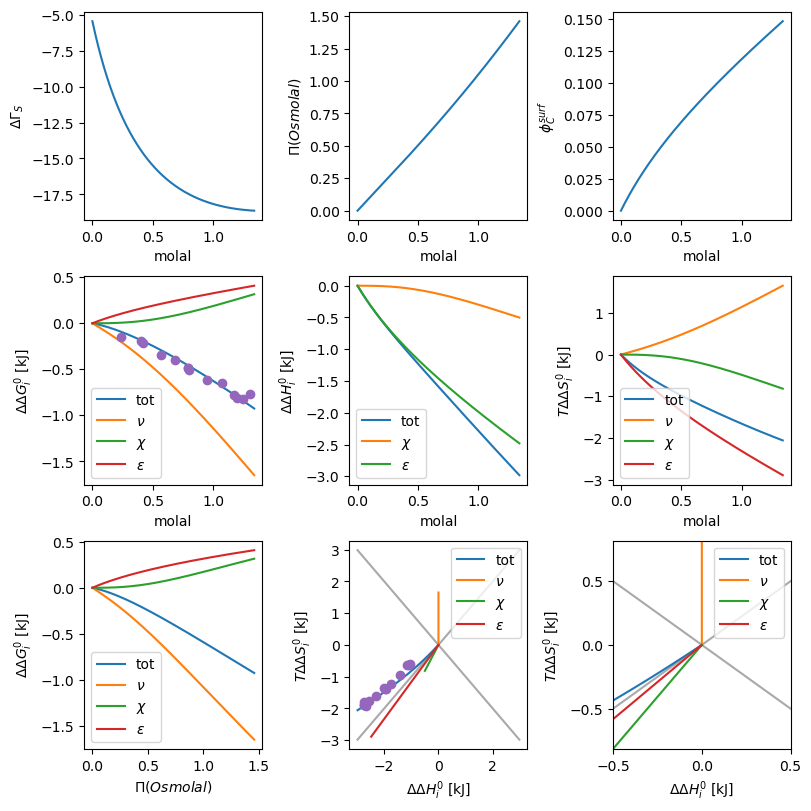

In [9]:
plotter = cr.Plotter(model)

# The plotter will overlay the experimental scatter points over the solved model lines
fig = plotter.plot_results(
    concentration_type='molal',
    exp_conc=exp_conc_G,
    exp_ddG=exp_dG,
    exp_ddH=exp_dH,
    exp_TddS=exp_TdS
)
plt.show()

## Exporting the Model Results
Now that the model is fully fitted and solved across the concentration grid, we can convert it to a DataFrame and export it.

In [10]:
# Convert model grid results to a dataframe
model.to_pandas()
results = model.results
display(results.head())

# Export the dataframe
# results.to_csv("aq16_trehalose_fitted_model.csv", index=False)

# You can also access the fitted parameters directly for export:
params_dict = {
    "eps": model.eps,
    "epsTS": model.epsTS
}
print(f"Final Parameters: {params_dict}")

,phiC,phiCsurf,phiS,phiSsurf,molar,molal,osm,gamma_per_vol,gamma,gammaC_per_vol,...,ddA_chi_kJ,ddA_eps_kJ,ddA_kJ,ddE_chi_kJ,ddE_eps_kJ,ddE_kJ,TddS_nu_kJ,TddS_chi_kJ,TddS_eps_kJ,TddS_kJ
0,0.0001,0.000090,0.9999,0.999910,0.000475,0.000475,0.000475,-0.095443,-5.444373,8.158309e-07,...,5.577290e-09,0.000249,-0.000115,-8.848956e-09,-0.001516,-0.001516,0.000365,-1.442625e-08,-0.001765,-0.001400
1,0.0002,0.000181,0.9998,0.999819,0.000950,0.000950,0.000950,-0.095769,-5.462973,1.637400e-06,...,2.246186e-08,0.000499,-0.000231,-3.563810e-08,-0.003030,-0.003030,0.000729,-5.809995e-08,-0.003529,-0.002800
2,0.0003,0.000271,0.9997,0.999729,0.001425,0.001425,0.001425,-0.096094,-5.481546,2.464697e-06,...,5.088340e-08,0.000748,-0.000347,-8.073187e-08,-0.004544,-0.004544,0.001095,-1.316153e-07,-0.005292,-0.004197
3,0.0004,0.000361,0.9996,0.999639,0.001899,0.001900,0.001900,-0.096419,-5.500092,3.297711e-06,...,9.107251e-08,0.000997,-0.000463,-1.444961e-07,-0.006056,-0.006056,0.001460,-2.355686e-07,-0.007053,-0.005593
4,0.0005,0.000452,0.9995,0.999548,0.002374,0.002375,0.002375,-0.096744,-5.518609,4.136431e-06,...,1.432606e-07,0.001246,-0.000579,-2.272980e-07,-0.007567,-0.007567,0.001825,-3.705586e-07,-0.008813,-0.006988


Final Parameters: {'eps': -0.044281058769175576, 'epsTS': 0.3132904280918789}
